# App Respondents – Quick EDA (planning)

Goal: inspect the raw CSV, spot data quirks, and decide which plots to build next.

In [22]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

data_path = Path('..')/ ('..') / 'data' / 'raw' / 'app-respondents.csv'
data_path

WindowsPath('../../data/raw/app-respondents.csv')

In [23]:
df = pd.read_csv(data_path)
#removed name
df = df.drop(columns=['Name'])
df.head()

,Age,Sex,Occupation,F1,F2,F3,P1,P2,P3,I1,I2,I3,M1,M2,M3,C1,C2,C3,Comment #1,Comment #2,Department
0,25,f,CLA,5,5,5,5,5,5,4,5,5,5,5,5,5,5,5,na,na,IT
1,24,m,ITSO,5,5,5,5,5,5,5,5,5,4,5,5,5,5,5,na,na,IT
2,24,m,CLA,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,na,na,IT
3,23,m,fullstack dev,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,na,more ui consistentcy,IT
4,26,m,fullstack dev,5,4,5,5,5,5,5,5,5,5,4,5,5,5,5,na,na,IT


In [24]:
df.shape, df.columns.tolist()

((50, 21),
 ['Age',
  'Sex',
  'Occupation',
  'F1',
  'F2',
  'F3',
  'P1',
  'P2',
  'P3',
  'I1',
  'I2',
  'I3',
  'M1',
  'M2',
  'M3',
  'C1',
  'C2',
  'C3',
  'Comment #1',
  'Comment #2',
  'Department'])

In [28]:
# Basic cleaning helpers for profiling only (do not overwrite df yet)
rating_prefixes = ['F', 'P', 'I', 'M', 'C']
rating_cols = [c for c in df.columns if any(c.startswith(p) for p in rating_prefixes)]
#remove Comment 1 and Comment 2 from rating_cols
rating_cols = [c for c in rating_cols if c not in ['Comment #1', 'Comment #2']]
comment_cols = [c for c in df.columns if 'Comment' in c]
meta_cols = [c for c in df.columns if c not in rating_cols + comment_cols]

df_clean = df.copy()
df_clean['Sex_norm'] = df_clean['Sex'].str.strip().str.lower().replace({'f': 'f', 'm': 'm'})
df_clean['Department_norm'] = df_clean['Department'].str.strip()
df_clean['Age_num'] = pd.to_numeric(df_clean['Age'], errors='coerce')

rating_cols, comment_cols, meta_cols

(['F1',
  'F2',
  'F3',
  'P1',
  'P2',
  'P3',
  'I1',
  'I2',
  'I3',
  'M1',
  'M2',
  'M3',
  'C1',
  'C2',
  'C3'],
 ['Comment #1', 'Comment #2'],
 ['Age', 'Sex', 'Occupation', 'Department'])

In [29]:
df_clean.head()

,Age,Sex,Occupation,F1,F2,F3,P1,P2,P3,I1,I2,I3,M1,M2,M3,C1,C2,C3,Comment #1,Comment #2,Department,Sex_norm,Department_norm,Age_num
0,25,f,CLA,5,5,5,5,5,5,4,5,5,5,5,5,5,5,5,na,na,IT,f,IT,25
1,24,m,ITSO,5,5,5,5,5,5,5,5,5,4,5,5,5,5,5,na,na,IT,m,IT,24
2,24,m,CLA,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,na,na,IT,m,IT,24
3,23,m,fullstack dev,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,na,more ui consistentcy,IT,m,IT,23
4,26,m,fullstack dev,5,4,5,5,5,5,5,5,5,5,4,5,5,5,5,na,na,IT,m,IT,26


In [30]:
df_clean['Age_num'].describe()

count    50.000000
mean     31.100000
std      10.614295
min      18.000000
25%      23.000000
50%      28.000000
75%      35.750000
max      58.000000
Name: Age_num, dtype: float64

In [31]:
sex_counts = df_clean['Sex_norm'].value_counts(dropna=False)
dept_counts = df_clean['Department_norm'].value_counts(dropna=False)
sex_counts, dept_counts

(Sex_norm
 f    37
 m    13
 Name: count, dtype: int64,
 Department_norm
 GU    20
 IT    15
 HP    15
 Name: count, dtype: int64)

C:\Users\johnc\AppData\Local\Temp\ipykernel_12156\634494633.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


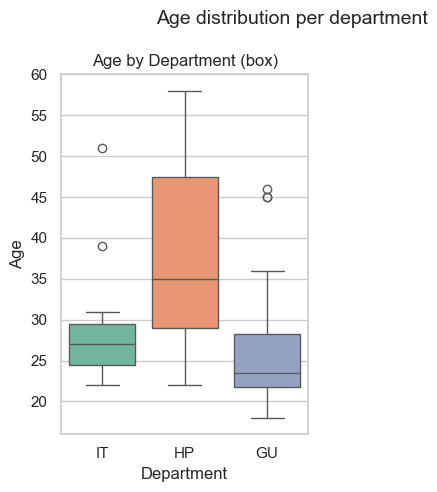

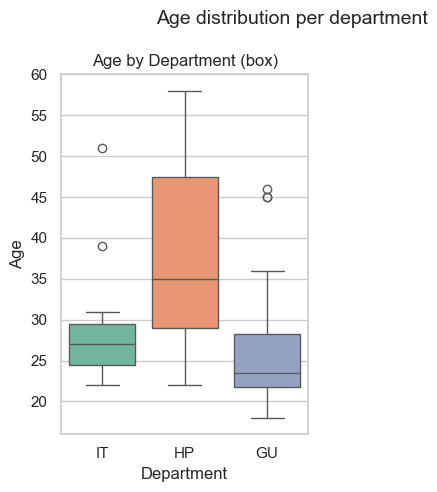

In [47]:
#just boxplot for age by department
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.boxplot(
    data=df_clean,
    x='Department_norm',
    y='Age_num',
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title('Age by Department (box)')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Age')

# sns.violinplot(
#     data=df_clean,
#     x='Department_norm',
fig.delaxes(axes[1])
fig.set_size_inches(6, 5)
#     inner='quartile',
#     cut=0,
#     ax=axes[1],
#     palette='Set2'
# )
# axes[1].set_title('Age by Department (violin)')
# axes[1].set_xlabel('Department')
# axes[1].set_ylabel('Age')

fig.suptitle('Age distribution per department', fontsize=14)
fig.tight_layout()
fig

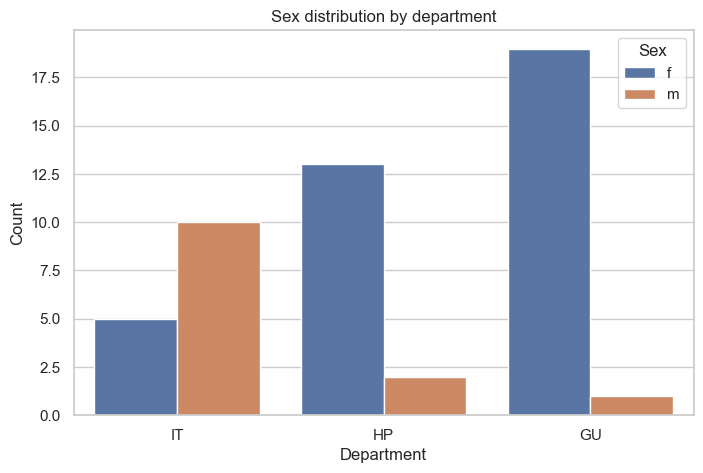

In [49]:
#sex distribution by department
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_clean,
    x='Department_norm',
    hue='Sex_norm'
)
plt.title('Sex distribution by department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.legend(title='Sex')
plt.show()

In [42]:
# Summary stats for rating columns for each department
grouped = df_clean.groupby('Department_norm')[rating_cols].describe()
rating_describe = grouped.loc[:, (slice(None), ['mean'])]
rating_describe.columns = [f'{col}_{stat}' for col, stat in rating_describe.columns]
rating_describe

,F1_mean,F2_mean,F3_mean,P1_mean,P2_mean,P3_mean,I1_mean,I2_mean,I3_mean,M1_mean,M2_mean,M3_mean,C1_mean,C2_mean,C3_mean
Department_norm,,,,,,,,,,,,,,,
GU,4.700000,4.950000,4.800000,4.800000,4.850000,4.950000,4.9,4.850000,4.800000,4.650000,4.800000,4.750000,4.900000,4.800000,4.85
HP,4.933333,4.733333,4.733333,4.866667,4.866667,4.866667,4.8,4.933333,4.866667,4.866667,4.866667,4.933333,4.866667,4.866667,4.80
IT,4.800000,4.666667,4.600000,4.800000,4.733333,4.733333,4.6,4.533333,4.666667,4.733333,4.666667,4.800000,4.800000,4.666667,4.80


In [41]:
rating_describe = df_clean[rating_cols].describe().T[['mean', 'std', 'min', 'max']]
rating_describe

,mean,std,min,max
F1,4.80,0.404061,4.0,5.0
F2,4.80,0.451754,3.0,5.0
F3,4.72,0.453557,4.0,5.0
P1,4.82,0.388088,4.0,5.0
P2,4.82,0.388088,4.0,5.0
P3,4.86,0.350510,4.0,5.0
I1,4.78,0.418452,4.0,5.0
I2,4.78,0.464670,3.0,5.0
I3,4.78,0.418452,4.0,5.0
M1,4.74,0.443087,4.0,5.0


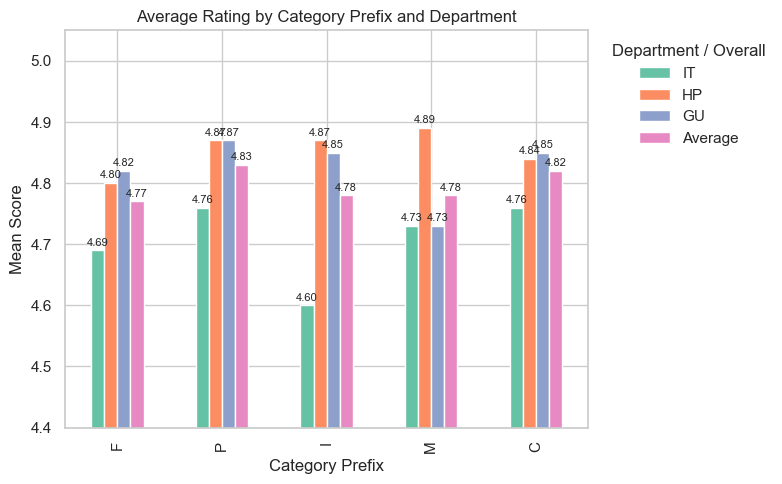

,IT,HP,GU,Average
F,4.69,4.80,4.82,4.77
P,4.76,4.87,4.87,4.83
I,4.60,4.87,4.85,4.78
M,4.73,4.89,4.73,4.78
C,4.76,4.84,4.85,4.82


In [51]:
prefixes = ['F', 'P', 'I', 'M', 'C']
dept_group = df_clean.groupby('Department_norm')
rows = []
for prefix in prefixes:
    cols = [c for c in rating_cols if c.startswith(prefix)]
    dept_vals = dept_group[cols].mean().mean(axis=1)  # mean across items for each dept
    overall = df_clean[cols].mean().mean()
    row = dept_vals.to_dict()
    row['Average'] = overall

    # plot once on the last prefix
    if prefix == prefixes[-1]:
        preview = pd.DataFrame(rows + [pd.Series(row, name=prefix)])[['IT', 'HP', 'GU', 'Average']].round(2)
        ax = preview.plot(kind='bar', figsize=(8, 5), color=sns.color_palette('Set2', 4))
        ax.set_title('Average Rating by Category Prefix and Department')
        ax.set_xlabel('Category Prefix')
        ax.set_ylabel('Mean Score')
        ax.legend(title='Department / Overall', loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)
        ax.set_ylim(4.4, 5.05)

        # add value labels for quicker comparison
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)
        plt.tight_layout()
        plt.show()
    rows.append(pd.Series(row, name=prefix))
prefix_means = pd.DataFrame(rows)[['IT', 'HP', 'GU', 'Average']].round(2)
prefix_means

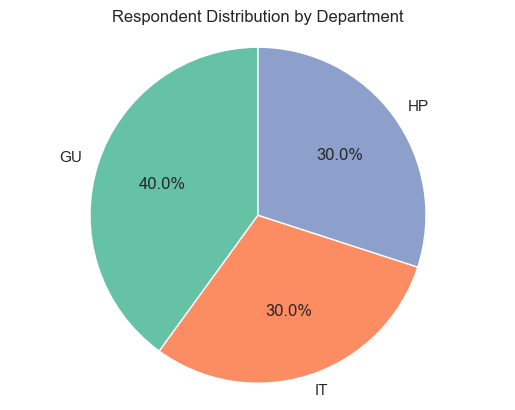

In [45]:
#pie chart for department
dept_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
plt.title('Respondent Distribution by Department')
plt.ylabel('')
plt.axis('equal')
plt.show()